In [ ]:
# 在当前 Jupyter 内核中安装 d2l 教学库。
# 使用 %pip（而不是 !pip）可以保证安装到“当前笔记本正在使用的 Python 环境”。
# --no-deps 表示不额外安装依赖，避免重复安装；--quiet 减少输出信息。
%pip install d2l --no-deps --quiet

In [ ]:
# 导入 PyTorch 主库，用于张量运算、自动求导与模型训练。
import torch

# 从 torch 中导入 nn 模块，后续会用到 GRU、Linear、Embedding 等网络层。
from torch import nn

# 导入 d2l 的 PyTorch 版本工具，包含 Seq2SeqEncoder、AdditiveAttention、训练工具等。
from d2l import torch as d2l

In [ ]:
# 定义“带注意力权重可访问接口”的解码器抽象基类。
class AttentionDecoder(d2l.Decoder):
    # 构造函数：接收 d2l.Decoder 需要的可选参数。
    def __init__(self, **kwargs):
        # 调用父类构造函数，完成基础解码器初始化。
        super(AttentionDecoder, self).__init__(**kwargs)
    
    # 使用 @property 暴露 attention_weights 属性，便于外部可视化注意力。
    @property
    def attention_weights(self):
        # 这里只定义接口，不给具体实现；子类必须覆盖该属性。
        raise NotImplementedError

In [ ]:
# 定义 Bahdanau（加性）注意力版 Seq2Seq 解码器。
class Seq2SeqAttentionDecoder(AttentionDecoder):
    # vocab_size: 目标词表大小；embed_size: 词向量维度；num_hiddens: 隐状态维度；num_layers: GRU 层数。
    # dropout: Dropout 概率，用于缓解过拟合。
    def __init__(self, vocab_size, embed_size, num_hiddens, num_layers,
                 dropout=0, **kwargs):
        # 初始化父类。
        super(Seq2SeqAttentionDecoder, self).__init__(**kwargs)
        # 加性注意力层：内部会学习 query 与 key 的匹配打分函数。
        # 注意，新版本d2l.AdditiveAttention内部使用了LazyLinear，不能与书上示例完全一致。
        self.attention = d2l.AdditiveAttention(num_hiddens, dropout)
        # 词嵌入层：把 token id 映射为稠密向量。
        self.embedding = nn.Embedding(vocab_size, embed_size)
        # GRU 输入维度 = [当前词嵌入 embed_size] + [上下文向量 num_hiddens]。
        self.rnn = nn.GRU(
            embed_size + num_hiddens, num_hiddens, num_layers,
            dropout=dropout)
        # 输出层：把 GRU 隐状态映射到目标词表 logits。
        self.dense = nn.Linear(num_hiddens, vocab_size)

    # 初始化解码器状态。
    # enc_outputs: 编码器输出（不同 d2l 版本返回结构略有差异）。
    # enc_valid_lens: 源序列有效长度，用于注意力掩码。
    def init_state(self, enc_outputs, enc_valid_lens, *args):
        # 显式占位，表示我们有意忽略额外参数（用于兼容不同调用签名）。
        _ = args

        # 兼容不同 d2l 版本：enc_outputs 可能是 (outputs, hidden_state)
        # 或 (outputs, hidden_state, 其他附加信息)。
        if isinstance(enc_outputs, (tuple, list)) and len(enc_outputs) >= 2:
            # outputs 形状通常是 (num_steps, batch_size, num_hiddens)
            # hidden_state 形状通常是 (num_layers, batch_size, num_hiddens)
            outputs, hidden_state = enc_outputs[0], enc_outputs[1]
        else:
            # 如果格式不合法，主动报错，避免静默失败。
            raise ValueError("enc_outputs should contain at least outputs and hidden_state")
        # 将 outputs 变为 (batch_size, num_steps, num_hiddens)，便于注意力按 batch 处理。
        # permute(1, 0, 2): 第 0/1 维互换。
        return (outputs.permute(1, 0, 2), hidden_state, enc_valid_lens)

    # 前向传播。
    # X: 解码器输入 token id，形状 (batch_size, num_steps)。
    # state: 上一步状态，包含 enc_outputs、hidden_state、enc_valid_lens。
    def forward(self, X, state):
        # 解包状态。
        enc_outputs, hidden_state, enc_valid_lens = state
        # 先做词嵌入，再转成时间步优先：
        # self.embedding(X) -> (batch_size, num_steps, embed_size)
        # permute(1, 0, 2) -> (num_steps, batch_size, embed_size)
        X = self.embedding(X).permute(1, 0, 2)
        # outputs: 收集每个时间步 GRU 输出；_attention_weights: 收集每步注意力权重。
        outputs, self._attention_weights = [], []
        # 逐时间步解码。x 形状为 (batch_size, embed_size)。
        for x in X:
            # 使用当前最后一层隐状态作为 query。
            # hidden_state[-1] 形状 (batch_size, num_hiddens)，unsqueeze 后为 (batch_size, 1, num_hiddens)。
            query = torch.unsqueeze(hidden_state[-1], dim=1)
            # context 是注意力汇聚后的上下文向量，形状 (batch_size, 1, num_hiddens)。
            # keys/values 都取编码器输出 enc_outputs。
            context = self.attention(
                query, enc_outputs, enc_outputs, enc_valid_lens)
            # 把上下文向量与当前输入词嵌入拼接。
            # x 先扩一维变成 (batch_size, 1, embed_size)，再在最后一维拼接。
            # 因为Contex的形状是 (batch_size, 1, num_hiddens)，
            # 所以拼接后 x 的形状是 (batch_size, 1, embed_size + num_hiddens)。
            x = torch.cat((context, torch.unsqueeze(x, dim=1)), dim=-1)
            # GRU 期望输入形状为 (num_steps=1, batch_size, feature_dim)。
            # 因此把 x 从 (batch_size, 1, feature_dim) 变成 (1, batch_size, feature_dim)。
            out, hidden_state = self.rnn(x.permute(1, 0, 2), hidden_state)
            # 保存当前时间步输出 out，形状 (1, batch_size, num_hiddens)。
            outputs.append(out)
            # 保存当前时间步的注意力权重，便于后续可视化。
            self._attention_weights.append(self.attention.attention_weights)
        # 按时间维拼接，得到 (num_steps, batch_size, num_hiddens)。
        outputs = torch.cat(outputs, dim=0)
        # 经过线性层映射到词表维度，得到 logits：
        # (num_steps, batch_size, vocab_size)。
        outputs = self.dense(outputs)
        # 返回给 d2l 训练接口所需形状：
        # outputs.permute(1, 0, 2) -> (batch_size, num_steps, vocab_size)。
        # 同时返回更新后的状态。
        return outputs.permute(1, 0, 2), [enc_outputs, hidden_state,
                                          enc_valid_lens]

    # 对外暴露每个时间步的注意力权重序列。
    @property
    def attention_weights(self):
        return self._attention_weights

In [ ]:
# ===== 用一个小例子快速验证编码器/解码器的张量形状是否正确 =====

# 创建一个 Seq2Seq 编码器：
# vocab_size=10: 词表大小；embed_size=8: 嵌入维度；num_hiddens=16: 隐状态维度；num_layers=2: GRU 层数。
encoder = d2l.Seq2SeqEncoder(vocab_size=10, embed_size=8, num_hiddens=16, num_layers=2)

# 切换到评估模式（关闭 Dropout 等训练专用行为）。
encoder.eval()

# 创建刚定义的 Bahdanau 注意力解码器，参数与编码器保持同规模。
decoder = Seq2SeqAttentionDecoder(vocab_size=10, embed_size=8, num_hiddens=16, num_layers=2)

# 切换到评估模式。
decoder.eval()

# 构造一批全 0 的输入 token id：
# batch_size=4，时间步 num_steps=7。
X = torch.zeros((4, 7), dtype=torch.long)  # (batch_size, num_steps)

# 先让编码器处理输入，再用编码器输出初始化解码器状态。
state = decoder.init_state(encoder(X), None)

# 让解码器跑一遍前向传播。
output, state = decoder(X, state)

# 打印关键形状与结构，确认维度流正确：
# output.shape: (batch_size, num_steps, vocab_size)
# len(state): 状态元组/列表长度
# state[0].shape: 编码器输出形状
# len(state[1]): GRU 层数
# state[1][0].shape: 某层隐状态形状
output.shape, len(state), state[0].shape, len(state[1]), state[1][0].shape

(torch.Size([4, 7, 10]), 3, torch.Size([4, 7, 16]), 2, torch.Size([4, 16]))

loss 0.020, 7366.7 tokens/sec on cuda:0


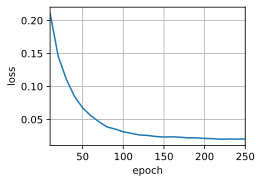

In [ ]:
# ===== 训练配置 =====
# embed_size: 词嵌入维度；num_hiddens: 隐状态维度；num_layers: RNN 层数；dropout: 随机失活比例。
embed_size, num_hiddens, num_layers, dropout = 32, 32, 2, 0.1

# batch_size: 每批样本数；num_steps: 句子最大时间步（超过会截断，不足会填充）。
batch_size, num_steps = 64, 10

# lr: 学习率；num_epochs: 训练轮数；device: 自动选择 GPU（若可用）或 CPU。
lr, num_epochs, device = 0.005, 250, d2l.try_gpu()

# 加载机器翻译数据集（英语->法语）。
# train_iter: 训练迭代器；src_vocab/tgt_vocab: 源/目标语言词表。
train_iter, src_vocab, tgt_vocab = d2l.load_data_nmt(batch_size, num_steps)

# 构建编码器。
encoder = d2l.Seq2SeqEncoder(
    len(src_vocab), embed_size, num_hiddens, num_layers, dropout)

# 构建带 Bahdanau 注意力的解码器。
decoder = Seq2SeqAttentionDecoder(
    len(tgt_vocab), embed_size, num_hiddens, num_layers, dropout)

# 组装为 Encoder-Decoder 总模型。
net = d2l.EncoderDecoder(encoder, decoder)

# 说明：不同 d2l 版本中，net(...) 的返回格式可能不同（有的直接返回张量，有的返回元组）。
# 这里自定义一个兼容训练函数，确保都能训练。
def train_seq2seq_compat(net, data_iter, lr, num_epochs, tgt_vocab, device):
    # 定义参数初始化函数（Xavier 初始化），常用于提升 RNN 训练稳定性。
    def xavier_init_weights(m):
        # 线性层权重用 Xavier 均匀分布初始化。
        if type(m) == nn.Linear:
            nn.init.xavier_uniform_(m.weight)
        # GRU 中多个内部权重矩阵也做 Xavier 初始化。
        if type(m) == nn.GRU:
            for param in m._flat_weights_names:
                if "weight" in param:
                    nn.init.xavier_uniform_(m._parameters[param])

    # 对整个网络递归应用初始化。
    net.apply(xavier_init_weights)
    # 把模型放到计算设备。
    net.to(device)

    # 使用 Adam 优化器。
    optimizer = torch.optim.Adam(net.parameters(), lr=lr)

    # 使用“带掩码”的交叉熵损失，忽略 padding 位置。
    loss = d2l.MaskedSoftmaxCELoss()

    # 切换到训练模式（启用 Dropout 等）。
    net.train()

    # 用于可视化训练损失。
    animator = d2l.Animator(xlabel='epoch', ylabel='loss', xlim=[10, num_epochs])

    # 外层循环：遍历 epoch。
    for epoch in range(num_epochs):
        # 计时器，用于统计 tokens/sec。
        timer = d2l.Timer()
        # metric[0] 累计总损失，metric[1] 累计 token 数。
        metric = d2l.Accumulator(2)

        # 内层循环：遍历每个 batch。
        for batch in data_iter:
            # 清空历史梯度。
            optimizer.zero_grad()

            # batch 包含：源句子 X、源有效长度、目标句子 Y、目标有效长度。
            # 并统一移动到 device 上。
            X, X_valid_len, Y, Y_valid_len = [x.to(device) for x in batch]

            # 构造解码器输入：第一个 token 是 <bos>（句子开始符）。
            bos = torch.tensor([tgt_vocab['<bos>']] * Y.shape[0],
                               device=device).reshape(-1, 1)

            # Teacher forcing：把目标序列右移一位作为解码器输入。
            # dec_input 形状 (batch_size, num_steps)。
            dec_input = d2l.concat([bos, Y[:, :-1]], 1)

            # 前向传播：预测目标序列每个位置的词分布。
            Y_hat = net(X, dec_input, X_valid_len)

            # 兼容处理：若返回 (Y_hat, state) 之类结构，只取预测张量。
            if isinstance(Y_hat, (tuple, list)):
                Y_hat = Y_hat[0]

            # 计算每个样本每个时间步的损失（内部会根据 Y_valid_len 做 mask）。
            l = loss(Y_hat, Y, Y_valid_len)

            # 反向传播（对 batch 内所有有效 token 损失求和）。
            l.sum().backward()

            # 梯度裁剪，防止 RNN 梯度爆炸。阈值设为 1。
            d2l.grad_clipping(net, 1)

            # 统计当前 batch 的有效 token 总数。
            num_tokens = Y_valid_len.sum()

            # 更新模型参数。
            optimizer.step()

            # 不跟踪梯度地更新统计量。
            with torch.no_grad():
                metric.add(l.sum(), num_tokens)

        # 每 10 个 epoch 记录一次平均 token 损失。
        if (epoch + 1) % 10 == 0:
            animator.add(epoch + 1, (metric[0] / metric[1],))

    # 打印最终损失与吞吐率。
    print(f'loss {metric[0] / metric[1]:.3f}, {metric[1] / timer.stop():.1f} '
          f'tokens/sec on {str(device)}')

# 启动训练。
train_seq2seq_compat(net, train_iter, lr, num_epochs, tgt_vocab, device)

In [ ]:
# ===== 用训练好的模型做翻译并计算 BLEU =====

# 准备若干英文测试句子。
engs = ['go .', "i lost .", 'he\'s calm .', 'i\'m home .']

# 对应参考法语（用于计算 BLEU）。
fras = ['va !', 'j\'ai perdu .', 'il est calme .', 'je suis chez moi .']

# 逐句翻译并输出结果。
for eng, fra in zip(engs, fras):
    # predict_seq2seq(..., True) 会额外返回解码时每一步注意力权重序列。
    translation, dec_attention_weight_seq = d2l.predict_seq2seq(
        net, eng, src_vocab, tgt_vocab, num_steps, device, True)

    # 输出翻译结果和 BLEU 分数（k=2 表示使用到 2-gram）。
    print(f'{eng} => {translation}, ',
          f'bleu {d2l.bleu(translation, fra, k=2):.3f}')

go . => va !,  bleu 1.000
i lost . => j'ai perdu .,  bleu 1.000
he's calm . => il est mouillé .,  bleu 0.658
i'm home . => je suis chez moi .,  bleu 1.000


In [ ]:
# ===== 整理最后一次翻译过程中每个解码步的注意力权重 =====

# dec_attention_weight_seq 中每个 step 都保存了该步注意力权重。
# 这里逐步取出并在“时间步维度”拼接，再 reshape 成热力图需要的 4 维格式：
# (num_rows=1, num_cols=1, num_queries=解码步数, num_keys=num_steps)
attention_weights = torch.cat(
    [step[0][0][0] for step in dec_attention_weight_seq], 0
).reshape((1, 1, -1, num_steps))

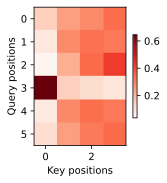

In [ ]:
# ===== 可视化注意力热图 =====
# 只可视化最后一句英文输入对应的有效 key 长度（再 +1 包含 <eos> 结束符）。
d2l.show_heatmaps(
    attention_weights[:, :, :, :len(engs[-1].split()) + 1].cpu(),
    xlabel='Key positions', ylabel='Query positions')